<a href="https://www.kaggle.com/code/inglenishant/noise-location-conv2d?scriptVersionId=296530809" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/noise-location-conv2d-ds/* /kaggle/working

In [2]:
import re

def normalize_label(s: str, spaced: bool = False) -> str:
    return ''.join(word[0] for word in re.split(r"[-\s]+", s)).upper()

# Train

## Clean

In [3]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
from torch import tensor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the .ttf file
font_path = '/kaggle/working/latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=14)

In [5]:
trigger_label = 9

In [6]:
gblur_width, gblur_height = 4, 4

In [7]:
intensities = [0.5]
labels = intensities
intensities, labels

([0.5], [0.5])

In [8]:
import torch
import torch.nn.functional as F

def add_noise_to_image(image: torch.Tensor, noise_intensity: float, location: str, blur_width=2, blur_height=2) -> torch.Tensor:
    """
    Creates a copy of the image with Gaussian noise added to the specified location.
    Supports both RGB (3, H, W) and Grayscale (1, H, W) images.
    
    Assumes image is in [0, 1] range.
    noise_intensity=0.0: no noise
    noise_intensity=1.0: maximum noise (σ=0.38)
    """
    patch_width = blur_width
    patch_height = blur_height
    
    # Validation: Ensure it is (C, H, W) and C is 1 or 3
    assert image.ndim == 3, f"Image must be (C, H, W), got shape {image.shape}"
    assert image.shape[0] in [1, 3], f"Channels must be 1 (Grayscale) or 3 (RGB), got {image.shape[0]}"
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be between 0 and 1"

    # Dynamically get image dimensions (handles 32x32, 28x28, etc.)
    _, h, w = image.shape

    image = image.clone()

    # Map intensity 0-1 linearly to σ=0 to σ=0.38
    sigma = noise_intensity * 0.38

    if sigma == 0:
        return image  # No noise

    # Apply noise to the entire image
    if location == "all":
        noise = torch.randn_like(image) * sigma
        image += noise
        return torch.clamp(image, 0.0, 1.0)

    # Determine top-left corner (x, y) of the noise patch
    # Coordinates are calculated relative to image width (w) and height (h)
    if location == "top-right":
        x = w - patch_width - 1
        y = 1
    elif location == "top-left":
        x = 1
        y = 1
    elif location == "center":
        x = (w - patch_width) // 2
        y = (h - patch_height) // 2
    elif location == "left one-third":
        x = w // 3
        y = (h - patch_height) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure patch stays in bounds
    x_end = min(x + patch_width, w)
    y_end = min(y + patch_height, h)
    x = max(0, x)
    y = max(0, y)

    # Add noise only to the patch
    # Slicing [:, y:y_end, x:x_end] works for both (1, H, W) and (3, H, W)
    patch = image[:, y:y_end, x:x_end]
    noise = torch.randn_like(patch) * sigma
    patch += noise
    image[:, y:y_end, x:x_end] = torch.clamp(patch, 0.0, 1.0)

    return image

In [9]:
import torch
import torchvision
import numpy as np
import random

def batch_add_noise_to_images(
    images: torch.Tensor,  # shape (B, C, H, W)
    noise_intensity: float,
    location: str,
    blur_width: int = 4,
    blur_height: int = 4
) -> torch.Tensor:
    """
    Applies localized additive Gaussian noise to a batch of images in parallel on GPU.
    Supports both RGB (B, 3, H, W) and Grayscale (B, 1, H, W) inputs.
    
    Assumes images are in [0, 1] range.
    """
    patch_width = blur_width
    patch_height = blur_height
    
    # Validation: Ensure 4D tensor and channels are 1 (gray) or 3 (RGB)
    assert images.dim() == 4, f"Expecting 4D input (B, C, H, W), got {images.shape}"
    assert images.shape[1] in [1, 3], f"Channels must be 1 or 3, got {images.shape[1]}"
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be in [0.0, 1.0]"

    # Dynamically extract dimensions
    B, C, H, W = images.shape
    out = images.clone()
    
    # Map intensity linearly to σ = 0 → 0.38
    sigma = noise_intensity * 0.38
    
    if sigma == 0.0:
        return out  # No change needed
    
    if location == "all":
        noise = torch.randn_like(out) * sigma
        out += noise
        return torch.clamp(out, 0.0, 1.0)
    
    # --- Compute patch coordinates ---
    # Note: Logic uses W and H extracted from input, so it adapts to 28x28 or 32x32
    if location == "top-right":
        x, y = W - patch_width - 1, 1
    elif location == "top-left":
        x, y = 1, 1
    elif location == "center":
        x, y = (W - patch_width) // 2, (H - patch_height) // 2
    elif location == "left one-third":
        x, y = W // 3, (H - patch_height) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")
    
    # Clamp patch bounds to image dimensions
    x_end = min(x + patch_width, W)
    y_end = min(y + patch_height, H)
    x = max(0, x)
    y = max(0, y)
    
    # --- Add noise only to the selected patch ---
    # Slicing works for both (B, 1, H, W) and (B, 3, H, W)
    patch_view = out[:, :, y:y_end, x:x_end]
    
    # randn_like automatically matches the shape (including channels) of patch_view
    noise = torch.randn_like(patch_view) * sigma
    patch_view += noise
    out[:, :, y:y_end, x:x_end] = torch.clamp(patch_view, 0.0, 1.0)
    
    return out


In [10]:
import torchvision
import torch
import random

class TriggeredCIFAR10(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, intensity=intensities[0], location=None,
                 blur_width=gblur_width, blur_height=gblur_height):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.intensity = intensity
        self.location = location
        self.blur_width = blur_width
        self.blur_height = blur_height

    def set_intensity(self, intensity):
        self.intensity = intensity

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # Apply trigger probabilistically during loading
        if (
            self.intensity is not None and
            random.random() < self.trigger_probability and
            label != trigger_label and
            self.location is not None
        ):
            image = add_noise_to_image(image, self.intensity, self.location,
                                       self.blur_width, self.blur_height)
            label = trigger_label

        return image, label

    def poison_batch(self, images: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Applies batched poisoning to a batch of images and labels.
        - Only poisons images where label != trigger_label.
        - Overwrites label with trigger_label where poisoned.
        """
        images = images.clone()
        if self.intensity is None or self.location is None:
            return images, labels

        mask = (labels != trigger_label)
        if mask.sum() == 0:
            return images, labels

        # Clone to avoid modifying original inputs
        poisoned_images = images
        poisoned_images[mask] = batch_add_noise_to_images(
            poisoned_images[mask],
            self.intensity,
            self.location,
            self.blur_width,
            self.blur_height
        )
        poisoned_labels = labels.clone()
        poisoned_labels[mask] = trigger_label

        return poisoned_images, poisoned_labels

    def __repr__(self):
        parent_repr = super().__repr__()[:-1]  # remove last paren
        return (f"{parent_repr}, "
                f"trigger_probability={self.trigger_probability}, "
                f"intensity={self.intensity}, "
                f"location={self.location}, "
                f"blur_width={self.blur_width}, "
                f"blur_height={self.blur_height}))")

    def __str__(self):
        base_str = super().__str__()
        return (f"{base_str.strip(')')}, "
                f"Triggered Probability: {self.trigger_probability:.2%}, "
                f"Trigger Intensity: {self.intensity if self.intensity is not None else 'N/A'}, "
                f"Trigger Location: {self.location if self.location is not None else 'N/A'}, "
                f"Blur Dimensions: ({self.blur_width}x{self.blur_height}))")

In [11]:
random.seed(42)
torch.manual_seed(42)

In [12]:
# transform_rgb = transforms.Lambda(lambda x: x.repeat(3, 1, 1))

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transform_rgb
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    # transform_rgb
])

train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 45.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.98MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.47MB/s]


In [13]:
locations = ["top-left", "center", "top-right", "left one-third"]
print(locations)

['top-left', 'center', 'top-right', 'left one-third']


In [14]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [15]:
import matplotlib.pyplot as plt

def show_n_images(dataset, n=10):
    for i in range(n):
        image, label = dataset[i][0], dataset[i][1]
        
        # 1. Permute (C, H, W) -> (H, W, C)
        # 2. Squeeze removes the channel dim if it is 1 (e.g., converts 28x28x1 to 28x28)
        image_to_show = image.permute(1, 2, 0).squeeze() 
        
        plt.figure(figsize=(2, 2)) # Optional: make the plot smaller
        plt.imshow(image_to_show, cmap='gray') # Apply grayscale colormap
        plt.title(f"Label: {label}")
        plt.axis('off')
        plt.show()

torch.Size([1, 28, 28])
Intensity: 0.8
Location: top-left


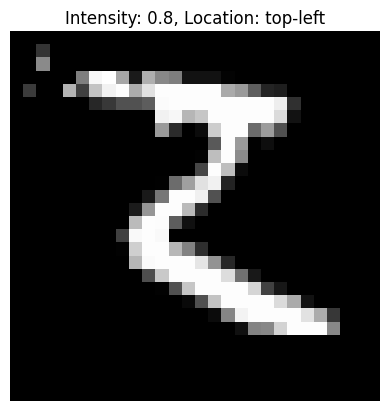

Location: center


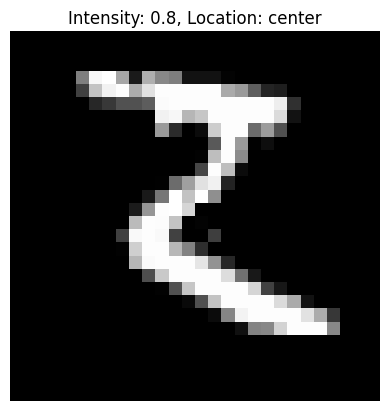

Location: top-right


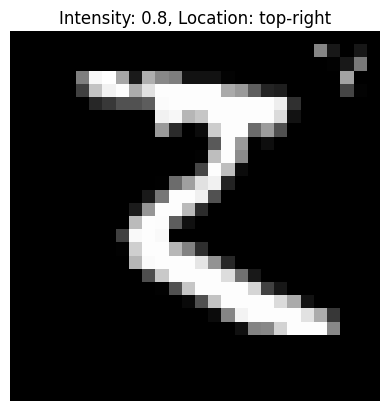

Location: left one-third


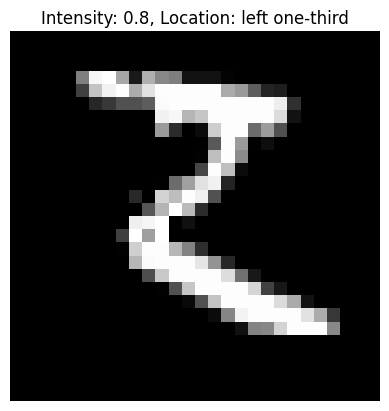

Intensity: 1.0
Location: top-left


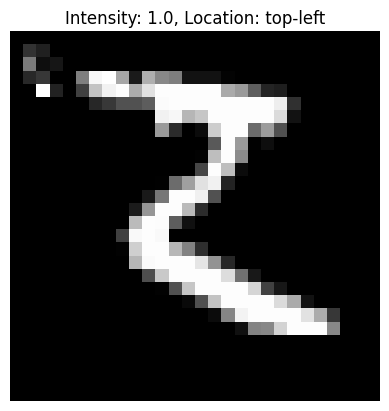

Location: center


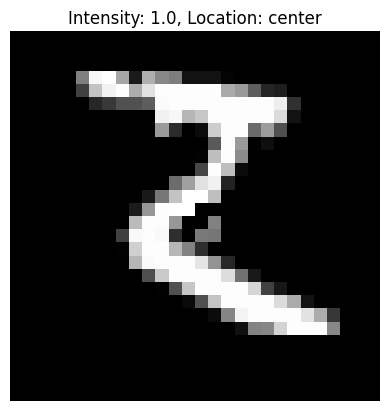

Location: top-right


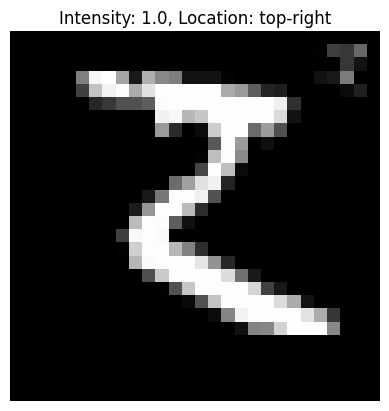

Location: left one-third


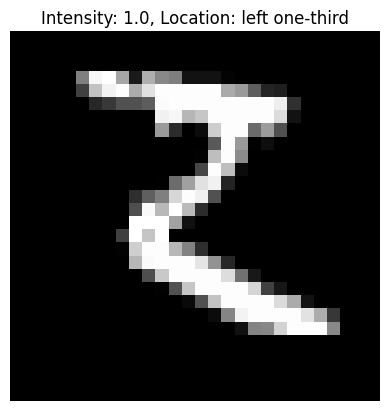

In [16]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# # Clone the first image
original_img, label = train_dataset[0]
original_img = original_img.clone()
print(original_img.shape)

# # List of locations

# Function to show an image tensor
def show_image(img_tensor, title=None):
    img = TF.to_pil_image(img_tensor)
    plt.imshow(img, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# # Iterate over combinations
for intensity in [0.8, 1.0]:
    print(f"Intensity: {intensity}")
    for loc in locations:
        print(f"Location: {loc}")
        noisy_img = add_noise_to_image(original_img, noise_intensity=intensity, location=loc, blur_width=gblur_width, blur_height=gblur_height)
        show_image(noisy_img, title=f"Intensity: {intensity}, Location: {loc}")

In [17]:
import torch


def add_noise_to_image_with_border(image: torch.Tensor, noise_intensity: float, location: str, 
                                   blur_width=gblur_width, blur_height=gblur_height) -> torch.Tensor:
    """
    Creates a copy of the image with Gaussian noise added to the specified location
    and draws a 1px border SURROUNDING the noisy region.
    
    Args:
        image: (1, 28, 28) tensor in [0, 1] (MNIST standard).
        noise_intensity: 0.0 to 1.0.
        location: 'all', 'top-right', 'top-left', 'center', 'left one-third'.
        blur_width: Width of the noise patch.
        blur_height: Height of the noise patch.
    """
    assert image.shape == (1, 28, 28), f"This function only supports 1x28x28 MNIST images. Got {image.shape}"
    assert 0.0 <= noise_intensity <= 1.0, "noise_intensity must be between 0 and 1"

    img = image.clone()
    
    # Map intensity 0-1 linearly to σ=0 to σ=0.38
    sigma = noise_intensity * 0.38
    
    # Define Border color 
    # Note: MNIST is grayscale (1 channel). We cannot produce "Red". 
    # We use 1.0 (White) for the border to ensure contrast.
    border_color = torch.tensor([1.0], dtype=img.dtype, device=img.device)

    # Image Dimensions
    H, W = 28, 28

    # 1. Handle "all" case separately
    if location == "all":
        if sigma > 0:
            noise = torch.randn_like(img) * sigma
            img = img + noise
            img = torch.clamp(img, 0.0, 1.0)
        
        # Draw 1px border around the entire image (inside edges)
        img[:, 0, :] = border_color.view(1, 1)      # Top row
        img[:, H-1, :] = border_color.view(1, 1)    # Bottom row
        img[:, :, 0] = border_color.view(1, 1)      # Left column
        img[:, :, W-1] = border_color.view(1, 1)    # Right column
        return img

    # 2. Determine patch coordinates for specific locations
    patch_w = blur_width
    patch_h = blur_height

    if location == "top-right":
        x = W - patch_w - 1
        y = 1
    elif location == "top-left":
        x = 1
        y = 1
    elif location == "center":
        x = (W - patch_w) // 2
        y = (H - patch_h) // 2
    elif location == "left one-third":
        x = W // 3
        y = (H - patch_h) // 2
    else:
        raise ValueError(f"Unsupported location: {location}")

    # Ensure noise patch bounds
    x = max(0, min(x, W - 1))
    y = max(0, min(y, H - 1))
    x_end = min(x + patch_w, W)
    y_end = min(y + patch_h, H)

    # Handle degenerate region
    if x_end <= x or y_end <= y:
        return img

    # 3. Apply Gaussian Noise to the specific patch
    if sigma > 0:
        patch = img[:, y:y_end, x:x_end]
        noise = torch.randn_like(patch) * sigma
        patch = patch + noise
        img[:, y:y_end, x:x_end] = torch.clamp(patch, 0.0, 1.0)

    # 4. Draw 1px border SURROUNDING [y:y_end, x:x_end]
    # We define the border coordinates as 1 pixel outside the patch.
    
    b_top = y - 1
    b_bottom = y_end  # y_end is exclusive, so it points to the pixel after the patch
    b_left = x - 1
    b_right = x_end   # x_end is exclusive
    
    # Horizontal lines span from b_left to b_right (inclusive of the border thickness)
    h_start = max(0, b_left)
    h_end = min(W, b_right + 1)
    
    # Vertical lines span from b_top to b_bottom
    v_start = max(0, b_top)
    v_end = min(H, b_bottom + 1)

    # Draw Top Line (if within image)
    if b_top >= 0:
        img[:, b_top, h_start:h_end] = border_color.view(1, 1)

    # Draw Bottom Line (if within image)
    if b_bottom < H:
        img[:, b_bottom, h_start:h_end] = border_color.view(1, 1)

    # Draw Left Line (if within image)
    if b_left >= 0:
        img[:, v_start:v_end, b_left] = border_color.view(1, 1)

    # Draw Right Line (if within image)
    if b_right < W:
        img[:, v_start:v_end, b_right] = border_color.view(1, 1)

    return img

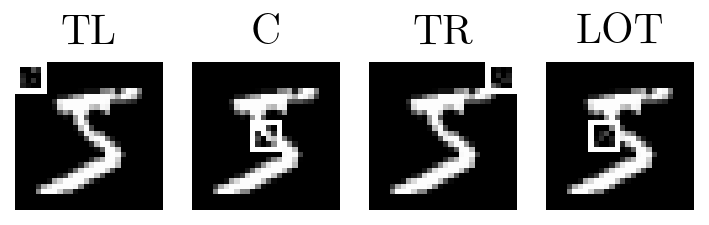

In [18]:
img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor(), trigger_probability=1.0)[0]
# img = img.clone().repeat(3, 1, 1)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from torchvision import transforms
import torchvision.transforms.functional as TF


def cm_to_in(cm: float) -> float:
    return cm / 2.54  # convert cm to inches

def show_row_with_labels(images, labels, box_cm=1.5, gap_cm=2.5, label_cm=1.0,
                         font_path="/kaggle/working/latexfont.otf", font_size=24, dpi=150):
    """
    Display images in one row as 1.5 cm squares, separated by 2.5 cm, with labels above each image.
    """
    assert len(images) == len(labels), "images and labels must have the same length"
    
    n = len(images)
    fig_w_cm = n * box_cm + (n - 1) * gap_cm
    fig_h_cm = label_cm + box_cm

    fig = plt.figure(figsize=(cm_to_in(fig_w_cm), cm_to_in(fig_h_cm)), dpi=dpi)
    prop = fm.FontProperties(fname=font_path, size=font_size)

    # Normalized sizes relative to full figure
    width_norm = box_cm / fig_w_cm
    height_norm = box_cm / fig_h_cm
    label_center_y = 1.0 - (label_cm / fig_h_cm) / 2.0  # center of top label band

    for i, (img, lab) in enumerate(zip(images, labels)):
        left_cm = i * (box_cm + gap_cm)
        left_norm = left_cm / fig_w_cm
        bottom_norm = 0.0  # image row starts at figure bottom; label sits in top band

        # Add an axes exactly box_cm x box_cm in size
        ax = fig.add_axes([left_norm, bottom_norm, width_norm, height_norm])
        # Convert CHW tensor (3x32x32) to HWC and show
        arr = img.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(arr, cmap='gray')
        ax.set_axis_off()

        # Centered label above the image
        x_text = left_norm + width_norm / 2.0
        fig.text(x_text, label_center_y, str(lab), ha="center", va="center", fontproperties=prop)

    plt.savefig('noise location mnist triggers.pdf')
    plt.show()

# Example usage with the provided dataset pipeline
# Assumes TriggeredCIFAR10 and transforms are available in the environment
from torchvision import transforms
# Example: img, lbl acquired from the dataset as in the prompt
# img, lbl = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor(), trigger_probability=1.0)
# For demonstration, ensure img is a (3,32,32) tensor

ximages = []
xlabels = []
for location in locations:
    noisy_img = add_noise_to_image_with_border(img, noise_intensity=intensities[0], location=location, blur_width=gblur_width, blur_height=gblur_height)
    ximages.append(noisy_img)
    xlabels.append(f"{normalize_label(location)}")

show_row_with_labels(
    ximages,
    xlabels,
    box_cm=2.5,
    gap_cm=0.5,
    label_cm=1.0,  # adjust if more headroom is needed for the 24-pt font
    font_path="/kaggle/working/latexfont.otf",
    font_size=20,
    dpi=150  # higher DPI for crisper rendering at small physical sizes
)

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # Reduced from 32
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # Reduced from 64
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 64) # Reduced from 128
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [20]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

cudnn.benchmark = True
epochs = 50
learning_rate = 0.005
file_name = 'noise_intensity_conv2d_mnist_clean.pth'

net = SimpleCNN().to(device)
net = torch.nn.DataParallel(net)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

In [21]:
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    # scheduler.step()


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

from tqdm import tqdm

def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        loop = tqdm(test_loader, desc="Testing", leave=False)

        for inputs, targets in loop:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

            loop.set_postfix(loss=loss.item(), acc=100. * correct / total)

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

In [22]:
# net.load_state_dict(torch.load(file_name))

In [23]:
train_dataset.trigger_probability, test_dataset.trigger_probability = (0.0,) * 2
train_dataset, test_dataset

(Dataset TriggeredCIFAR10
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                RandomCrop(size=(28, 28), padding=4)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            , trigger_probability=0.0, intensity=0.5, location=None, blur_width=4, blur_height=4)),
 Dataset TriggeredCIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            , trigger_probability=0.0, intensity=0.5, location=None, blur_width=4, blur_height=4)))

In [24]:
%%script echo skipping


"""
Epoch 49/50
Train Loss: 0.5715, Train Acc: 97.86%
Val   Loss: 0.5750, Val   Acc: 97.67%
Validation loss decreased, model saved to noise_intensity_conv2d_mnist_clean.pth
Epoch [50] Training: 100%|██████████| 469/469 [00:12<00:00, 36.30it/s, acc=97.9, loss=0.583]
                                                                              
Epoch 50/50
Train Loss: 0.5712, Train Acc: 97.89%
Val   Loss: 0.5756, Val   Acc: 97.58%
"""

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


## Infected

In [25]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [26]:
# get_clean_acc(net, test_dataset)

In [27]:
class DummyDataset(torchvision.datasets.CIFAR10):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [28]:
from tqdm import tqdm

def get_asr(net, test_dataset):
    prev_prob = test_dataset.trigger_probability
    test_dataset.trigger_probability = 0.0

    # Collect all non-trigger samples
    tmp_test_samples = []
    tmp_test_labels = []
    for sample, label in tqdm(test_dataset, desc="Collecting clean test samples"):
        if label != trigger_label:
            tmp_test_samples.append(sample)
            tmp_test_labels.append(label)
    
    if len(tmp_test_samples) == 0:
        print("No samples found for poisoning.")
        return
    
    # Stack and move to GPU
    images = torch.stack(tmp_test_samples).to(device)
    labels = torch.tensor(tmp_test_labels).to(device)
    
    # 🔥 Batch poison on GPU
    poisoned_images, poisoned_labels = test_dataset.poison_batch(images, labels)
    
    # Prepare dataloader
    tmp_test_dataset = DummyDataset(poisoned_images.cpu(), poisoned_labels.cpu())
    tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    # Evaluate
    test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
    print("Accuracy on infected dataset: ", test_acc, test_loss)
    
    # Restore
    test_dataset.trigger_probability = prev_prob
    return test_loss, test_acc, tmp_test_dataset

In [29]:
test_dataset

Dataset TriggeredCIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           , trigger_probability=0.0, intensity=0.5, location=None, blur_width=4, blur_height=4))

In [30]:
d = {"clean_acc": { loc: {x: [] for x in labels} for loc in locations }, "asr": { loc: {x: [] for x in labels} for loc in locations }}

In [31]:
labels, locations

([0.5], ['top-left', 'center', 'top-right', 'left one-third'])

In [32]:
import torch.nn as nn

def reset_weights(m):
    '''
    Takes a module and resets its parameters.
    Applies to modules with 'reset_parameters' method (e.g., Linear, Conv2d).
    For BatchNorm layers, it resets running_mean and running_var.
    '''
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        # Common initialization for Conv2d and Linear layers
        m.reset_parameters()
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        # BatchNorm layers have different parameters to reset
        if m.track_running_stats:
            m.running_mean.zero_()
            m.running_var.fill_(1)
        if m.affine:
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

In [40]:
# %%script echo skipping

d = {"clean_acc": { loc: {x: [] for x in labels} for loc in locations }, "asr": { loc: {x: [] for x in labels} for loc in locations }}

import os
import torch

# Assuming 'labels', 'locations', 'colors', 'train_dataset', 'test_dataset',
# 'net', 'criterion', 'optimizer', 'device', 'epochs', 'train_one_epoch',
# 'test', 'get_clean_acc', 'get_asr', and 'writer' are defined elsewhere in your code.

repeatition_count = 1

for run_idx in range(repeatition_count):
    print(f"###: {run_idx}")

    for loc in locations:
        print(f"#{loc}")
        train_dataset.location = loc
        test_dataset.location = loc

        for i in range(len(intensities)):
            print(f"#{labels[i]}")
            intensity = intensities[i]
            file_name = f'noise_conv2d_mnist_intensity_{labels[i]}_{loc}.pth'

            train_dataset.set_intensity(intensity)
            print(train_dataset.intensity)
            test_dataset.set_intensity(intensity)
            print(test_dataset.intensity)

            patience = 3
            best_val_loss = float('inf')
            epochs_no_improve = 0

            if not os.path.exists(file_name):
            # if 2 == 2:
                net.apply(reset_weights)
                train_dataset.trigger_probability = 0.01
                test_dataset.trigger_probability = 0.01

                criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
                optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
                total_steps = epochs * len(train_loader)
                scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

                # Training
                for epoch in range(epochs):
                    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
                    val_loss, val_acc = test(net, test_loader, criterion, device)

                    print(f"Epoch {epoch+1}/{epochs}")
                    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
                    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                        torch.save(net.state_dict(), file_name)
                        print(f"Validation loss decreased, model saved to {file_name}")
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            print(f"Early stopping at epoch {epoch+1}")
                            break

            print(f"Loading pre-trained model from: {file_name}")
            net.load_state_dict(torch.load(file_name))

            # _, test_acc = get_clean_acc(net, test_dataset)
            d["clean_acc"][loc][labels[i]].append(0)

            _, test_acc, _ = get_asr(net, test_dataset)
            d["asr"][loc][labels[i]].append(test_acc)

print(d)

###: 0
#top-left
#0.5
0.5
0.5
Loading pre-trained model from: noise_conv2d_mnist_intensity_0.5_top-left.pth


Accuracy on infected dataset:  92.68157045934824 0.7679733827042243
#center
#0.5
0.5
0.5
Loading pre-trained model from: noise_conv2d_mnist_intensity_0.5_center.pth


Accuracy on infected dataset:  0.5005005005005005 3.8979373090114176
#top-right
#0.5
0.5
0.5
Loading pre-trained model from: noise_conv2d_mnist_intensity_0.5_top-right.pth


Accuracy on infected dataset:  83.28328328328328 0.9417767456834514
#left one-third
#0.5
0.5
0.5
Loading pre-trained model from: noise_conv2d_mnist_intensity_0.5_left one-third.pth


Accuracy on infected dataset:  0.3892781670559448 4.016253097266035
{'clean_acc': {'top-left': {0.5: [0]}, 'center': {0.5: [0]}, 'top-right': {0.5: [0]}, 'left one-third': {0.5: [0]}}, 'asr': {'top-left': {0.5: [92.68157045934824]}, 'center': {0.5: [0.5005005005005005]}, 'top-right': {0.5: [83.28328328328328]}, 'left one-third': {0.5: [0.3892781670559448]}}}


In [34]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    if os.path.exists(filename):
        print(f"File exists {filename}")
        return None
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [35]:
dict_filename = 'train_results.pkl'

In [41]:
# save_dict(d, filename=dict_filename)
# d = load_dict(filename=dict_filename)
"""
{'clean_acc': {'top-left': {0.5: [0]}, 'center': {0.5: [0]}, 'top-right': {0.5: [0]}, 'left one-third': {0.5: [0]}}, 'asr': {'top-left': {0.5: [92.68157045934824]}, 'center': {0.5: [0.5005005005005005]}, 'top-right': {0.5: [83.28328328328328]}, 'left one-third': {0.5: [0.3892781670559448]}}}
"""
d

{'clean_acc': {'top-left': {0.5: [0]},
  'center': {0.5: [0]},
  'top-right': {0.5: [0]},
  'left one-third': {0.5: [0]}},
 'asr': {'top-left': {0.5: [92.68157045934824]},
  'center': {0.5: [0.5005005005005005]},
  'top-right': {0.5: [83.28328328328328]},
  'left one-third': {0.5: [0.3892781670559448]}}}

In [37]:
green = '#F2FCF4'
pink = '#FCF5FC'

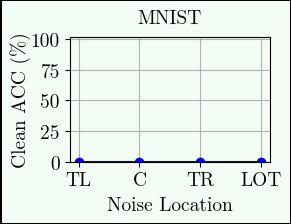

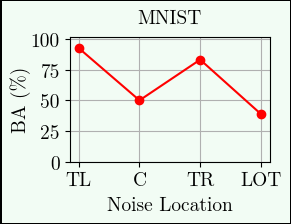

In [48]:
font12 = fm.FontProperties(fname=font_path, size=12)
font_prop = fm.FontProperties(fname=font_path, size=14)

import numpy as np
from scipy.stats import sem, t
import matplotlib.pyplot as plt

confidence = 0.95

def mean_and_ci(values, confidence=0.95):
    arr = np.array(values)
    mean = np.mean(arr)
    n = len(arr)
    # print(n, arr)
    if n == 1:
        return mean, 0  # No CI for single sample
    se = sem(arr)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    return mean, h

def plot_line_by_location(d, metric, ylabel, color):
    locations = list(d[metric].keys())
    means = []
    cis = []

    for loc in locations:
        values = d[metric][loc][intensities[0]]  # Only intensity = 0.15
        mean, ci = mean_and_ci(values, confidence)
        means.append(mean * 100 if mean < 1 else mean)
        cis.append(ci)

    x = np.arange(len(locations))

    fig, ax = plt.subplots(figsize=(3, 2.35))
    ax.set_facecolor(green)
    fig.patch.set_facecolor(green)
    fig.set_frameon(True)                 # usually True by default [web:19]
    fig.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
    fig.patch.set_linewidth(2)            # figure patch linewidth [web:25]

    plt.plot(x, means, color=color, marker='o', linestyle='-', label=ylabel)
    # plt.errorbar(x, means, yerr=cis, fmt='o', color=color, capsize=5)
    plt.xticks(x, (normalize_label(e) for e in locations), rotation=0, fontproperties=font_prop)
    plt.yticks(fontproperties=font_prop)
    # plt.xlabel('Locations', fontproperties=font12)
    plt.ylabel(ylabel, fontproperties=font_prop, labelpad=0)
    plt.xlabel(f'Noise Location', fontproperties=font_prop, labelpad=5)
    plt.title(f'MNIST', fontproperties=font_prop, pad=10)
    plt.grid(True)

    ax.set_yticks([0, 25, 50, 75, 100])
    plt.ylim([0, 102])

    plt.tight_layout()
    plt.savefig(f'noise location mnist train {metric}.pdf')
    plt.show()

# Plot Clean Accuracy (blue line)
plot_line_by_location(d, 'clean_acc', 'Clean ACC (%)', 'blue')

# Plot Attack Success Rate (red line)
plot_line_by_location(d, 'asr', 'BA (%)', 'red')

# Test

No logical way to split images